In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
# architecture
class EmbedWipeout(nn.Module):
    def __init__(self, h=28, w=28, n=28*28, l=10):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(h*w, n),
        )
        #self.activation = nn.ReLU()
        self.norm = nn.LayerNorm(n)
        self.wipeout = nn.Linear(n, l, bias=False)

    def forward(self, x):
        hidden = self.norm(self.embed(x))
        #hidden = self.activation(self.embed(x))
        logits = self.wipeout(hidden)
        if self.training:
            return logits
        else:
            return F.softmax(logits, dim=1)

In [4]:
# create classifier
model = EmbedWipeout(28,28,3,4).to(device)

In [5]:
# get datasets
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())

In [6]:
classes_to_keep = {0, 6, 8, 9}
class_to_id = {class_: i for i, class_ in enumerate(classes_to_keep)}
print(class_to_id)
id_to_class = {i: class_ for class_, i in class_to_id.items()}
print(id_to_class)

{0: 0, 8: 1, 6: 2, 9: 3}
{0: 0, 1: 8, 2: 6, 3: 9}


In [7]:
from torch.utils.data import Dataset

class RemappedSubset(Dataset):
    def __init__(self, original_dataset, indices, class_to_new):
        self.original = original_dataset
        self.indices = indices
        self.class_to_new = class_to_new

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x, y = self.original[real_idx]
        new_y = self.class_to_new[int(y)]
        return x, new_y

In [8]:
# create subset
train_indices = [i for i, (_, label) in enumerate(train_dataset) if label in classes_to_keep] # indices for train subset
test_indices = [i for i, (_, label) in enumerate(test_dataset) if label in classes_to_keep] # indices for test subset
train_subset = RemappedSubset(train_dataset, train_indices, class_to_id)
test_subset = RemappedSubset(test_dataset, test_indices, class_to_id)

In [9]:
labels = torch.tensor([label for _, label in train_subset])
print(torch.unique(labels))
labels = torch.tensor([label for _, label in test_subset])
print(torch.unique(labels))

tensor([0, 1, 2, 3])
tensor([0, 1, 2, 3])


In [10]:
# create train and test dataloader
batch_size = 512
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [11]:
# Define loss funcion
criterion = nn.CrossEntropyLoss()

In [12]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
# scheduler
step_size = 16
gamma = 0.7
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

In [14]:
# training
history_loss = []
history_acc = []
history_test_acc = []
epoch = 0

In [15]:
def train(num_epochs):
    global epoch
    for _ in range(num_epochs):
        # change model in training mood
        model.train()

        # to record loss and accuracy
        batch_loss = []
        total_train = 0
        correct_train = 0

        for batch, (x_train, y_train) in enumerate(train_loader):

            # send data to device
            input = x_train.to(device)

            # reset parameters gradient to zero
            optimizer.zero_grad()

            # forward pass to the model
            output = model(input)

            # categorization
            expected_output = y_train.to(device)

            # cross entropy loss
            loss = criterion(output, expected_output)

            # find gradients
            loss.backward()
            # update parameters using gradients
            optimizer.step()

            # recording loss
            batch_loss.append(loss.item())

            # recording accuracy
            total_train += output.shape[0]
            correct_train += torch.argmax(output,dim=1).to('cpu').eq(y_train).sum().item()

        epoch_loss = np.average(batch_loss)
        epoch_acc = (100.0 * correct_train) / total_train

        history_loss.append(epoch_loss)
        history_acc.append(epoch_acc)

        total_test = 0
        correct_test = 0

        model.eval()

        for batch, (x_test, y_test) in enumerate(test_loader):

            # send data to device
            input = x_test.to(device)

            # forward pass to the model
            with torch.no_grad():
                output = model(input)

            # recording accuracy
            total_test += output.shape[0]
            correct_test += torch.argmax(output,dim=1).to('cpu').eq(y_test).sum().item()

        test_acc = (100.0 * correct_test) / total_test

        history_test_acc.append(test_acc)

        print(f'Epoch: {epoch} Loss: {epoch_loss:.6f} Accuracy: {epoch_acc:.4f} Test accuracy: {test_acc:.4f} Learning Rate: {scheduler.get_last_lr()[0]:.7f}')
        scheduler.step()
        epoch += 1

In [16]:
# training
print(f"number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
num_epochs = 70
train(num_epochs)

number of trainable parameters: 2373
Epoch: 0 Loss: 1.091915 Accuracy: 60.8900 Test accuracy: 68.8855 Learning Rate: 0.0010000
Epoch: 1 Loss: 0.928358 Accuracy: 73.0849 Test accuracy: 75.2614 Learning Rate: 0.0010000
Epoch: 2 Loss: 0.829159 Accuracy: 78.4273 Test accuracy: 80.5662 Learning Rate: 0.0010000
Epoch: 3 Loss: 0.742954 Accuracy: 83.9347 Test accuracy: 84.8763 Learning Rate: 0.0010000
Epoch: 4 Loss: 0.670896 Accuracy: 88.3888 Test accuracy: 89.7475 Learning Rate: 0.0010000
Epoch: 5 Loss: 0.612213 Accuracy: 89.9454 Test accuracy: 89.2629 Learning Rate: 0.0010000
Epoch: 6 Loss: 0.553077 Accuracy: 91.8108 Test accuracy: 91.5838 Learning Rate: 0.0010000
Epoch: 7 Loss: 0.499230 Accuracy: 92.9910 Test accuracy: 92.2724 Learning Rate: 0.0010000
Epoch: 8 Loss: 0.449589 Accuracy: 93.4901 Test accuracy: 92.8590 Learning Rate: 0.0010000
Epoch: 9 Loss: 0.409117 Accuracy: 93.8835 Test accuracy: 92.9610 Learning Rate: 0.0010000
Epoch: 10 Loss: 0.374049 Accuracy: 94.0865 Test accuracy: 92.93

In [17]:
def plot_history():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
    # Loss curve
    axes[0].plot(history_loss, 'r', linewidth=3.0)
    axes[0].set_title('Loss Curve', fontsize=16)
    axes[0].set_xlabel('Epochs', fontsize=14)
    axes[0].set_ylabel('Loss', fontsize=14)
    axes[0].legend(['Training Loss'], fontsize=12)
    # Accuracy curves
    axes[1].plot(history_acc, 'r', linewidth=3.0)
    axes[1].plot(history_test_acc, 'b', linewidth=3.0)
    axes[1].set_title('Accuracy Curves', fontsize=16)
    axes[1].set_xlabel('Epochs', fontsize=14)
    axes[1].set_ylabel('Accuracy', fontsize=14)
    axes[1].legend(['Training Accuracy', 'Validation Accuracy'], fontsize=12)
    plt.tight_layout()
    plt.show()

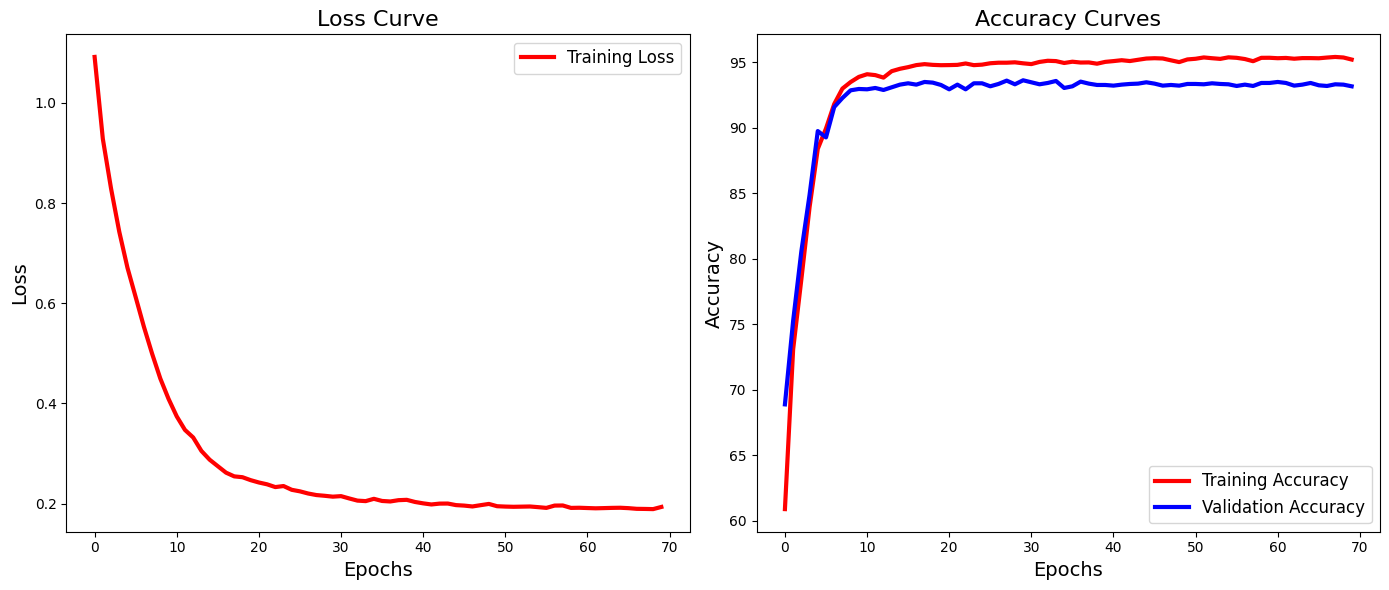

In [18]:
plot_history()

In [19]:
model.eval()

EmbedWipeout(
  (embed): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=3, bias=True)
  )
  (norm): LayerNorm((3,), eps=1e-05, elementwise_affine=True)
  (wipeout): Linear(in_features=3, out_features=4, bias=False)
)

In [20]:
# Save model and weights
def save(model_name):
    torch.save(model.state_dict(), model_name) # weights only
    print('Saved trained model at %s ' % model_name)

In [21]:
save('mnist_classifier_embed-wipeout.pth')

Saved trained model at mnist_classifier_embed-wipeout.pth 


In [22]:
#from google.colab import files
#files.download('mnist_classifier_embed-wipeout.pth')

In [23]:
vecs = model.wipeout.weight.detach().cpu().numpy()
print(vecs.shape)

(4, 3)


In [24]:
vecs

array([[ 0.40743434, -1.2428185 ,  0.23947246],
       [ 0.93318725,  0.59252435, -0.64900285],
       [-1.2340384 ,  0.7287228 , -0.6925394 ],
       [-0.93411976, -0.49939808,  1.1534377 ]], dtype=float32)

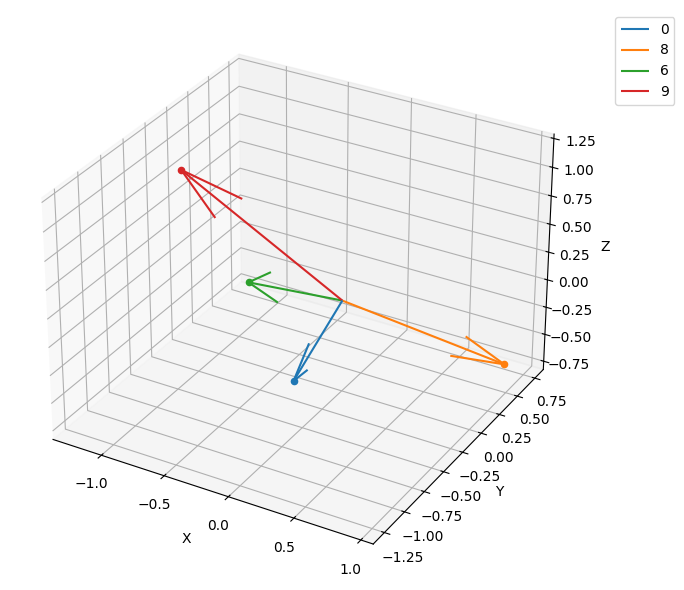

In [25]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# colormap with one distinct color per vector
colors = plt.cm.tab10(range(len(vecs)))

for i, v in enumerate(vecs):
    x, y, z = v.tolist()
    ax.quiver(0, 0, 0, x, y, z, color=colors[i], label=f"{id_to_class[i]}")
    ax.scatter([x], [y], [z], color=colors[i])

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# place legend outside plot for readability
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


In [26]:
from google.colab import files
_ = files.upload()

In [27]:
model = EmbedWipeout(28,28).to(device)
model.load_state_dict(torch.load('mnist_classifier_embed-wipeout.pth', weights_only=True))

RuntimeError: Error(s) in loading state_dict for EmbedWipeout:
	size mismatch for embed.1.weight: copying a param with shape torch.Size([3, 784]) from checkpoint, the shape in current model is torch.Size([784, 784]).
	size mismatch for embed.1.bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([784]).
	size mismatch for norm.weight: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([784]).
	size mismatch for norm.bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([784]).
	size mismatch for wipeout.weight: copying a param with shape torch.Size([4, 3]) from checkpoint, the shape in current model is torch.Size([10, 784]).

In [ ]:
sample = train_dataset[0]
print(sample[0].shape,sample[1])

In [ ]:
probabilities = model(sample[0].unsqueeze(0).to(device))
print(probabilities.argmax().item())

In [ ]:
sample_ = sample[0].squeeze(0).detach().numpy()
plt.imshow(sample_, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
def onehot(category, num_categories=10):
    one_hot = torch.zeros(num_categories).float()
    one_hot[category] = 1.0
    return one_hot

In [ ]:
def tv_loss(x):
    return torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:])) + \
           torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :]))

In [ ]:
lambda_tv = 0.1

In [ ]:
x = torch.randn((1, 1, 28, 28), requires_grad=True).sigmoid().to(device).clone().detach().requires_grad_(True)

In [ ]:
optimizer = torch.optim.Adam([x], lr=0.001)

In [ ]:
def bimodal_loss(x, eps=1e-6):
    # x is in [0,1]
    p = x.clamp(eps, 1-eps)
    entropy = -(p * torch.log(p) + (1 - p) * torch.log(1 - p))
    return entropy.mean()   # minimize entropy → push toward 0 and 1

In [ ]:
lambda_bi = 0.1

In [ ]:
category = 5
target_y = onehot(category).to(device)

In [ ]:
for step in range(50000):
    optimizer.zero_grad()

    x_ = x.sigmoid()
    pred = model(x_)

    loss = torch.nn.functional.mse_loss(pred, target_y) + lambda_tv * tv_loss(x_) + lambda_bi * bimodal_loss(x_)
    #loss = torch.nn.functional.cross_entropy(pred, target_y) + lambda_tv * tv_loss(x_)

    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        print(f"Step {step}, loss = {loss.item():.6f}")

In [ ]:
x_ = (x[0].sigmoid().squeeze(0).detach().cpu().numpy()*255).astype(np.uint8)
plt.imshow(x_, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
tv_loss(x.sigmoid())

In [ ]:
model(x.sigmoid()).argmax()

In [ ]:
representatives = model.wipeout[0].weight.detach().cpu().numpy()
print(representatives.shape)

In [ ]:
projection = model.embed[1].weight.detach().cpu().numpy()
bias = model.embed[1].bias.detach().cpu().numpy()
print(projection.shape)
print(bias.shape)

In [ ]:
print(sample_.shape)
inp = sample_.reshape(-1)
print(inp.shape)

In [ ]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

In [ ]:
def norm(x):
    return model.embed[2](torch.tensor(x).to(device)).cpu().detach().numpy()

In [ ]:
# result should be the same like from the model, yes it is
probabilities

In [ ]:
for category in range(10):
    logits = representatives[category] @ representatives.T
    print(logits.argmax().item())

In [ ]:
# algebraic forward
probabilities = softmax(norm(inp @ projection.T + bias) @ representatives.T)
print(probabilities)

In [ ]:
def inverseLayerNorm(module, y):
    gamma = module.weight
    beta = module.bias
    gamma = gamma.view(*([1] * (y.dim() - 1)), -1)
    beta = beta.view(*([1] * (y.dim() - 1)), -1)
    x = (y - beta) / gamma
    return x

In [ ]:
def invnorm(y):
    return inverseLayerNorm(model.embed[2],torch.tensor(y).to(device)).cpu().detach().numpy()

In [ ]:
projection.T @ np.linalg.inv(projection.T)

In [ ]:
# backprojection of representatives
# inverse value of softmax applied to one-hot encoding is the same one-hot value
# softmax(reprezentatives[category] @ representatives.T) == one-hot(category)
# norm(inp @ projection.T + bias) == representatives[category]
# ------------------------------
category = 5
inp = (invnorm(representatives[category])-bias) @ np.linalg.pinv(projection.T)
print(inp.shape)

In [ ]:
templet = inp.reshape(28,28)
plt.imshow(templet, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
model(torch.tensor(templet).unsqueeze(0).unsqueeze(0).to(device))

In [ ]:
fig = plt.figure(figsize=(16,6))
for category in range(10):
    inp = (invnorm(representatives[category])-bias) @ np.linalg.pinv(projection.T)
    templet = inp.reshape(28,28)
    plt.subplot(2,5,category+1)
    plt.imshow(templet, cmap='gray')
    plt.axis('off')

plt.show()